# Market Sentiment vs. Trader Performance Analysis

This notebook investigates the relationship between market sentiment (Fear vs. Greed) and retail trader behavior. By merging daily aggregated trader statistics with historical indices, we aim to uncover how emotional extremes influence profitability, risk-taking (trade size), and activity levels (trade count).

## 1. Data Loading
First, we import the necessary libraries and load our raw sentiment and trading transaction data.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [26]:
# Load datasets
sentiment_df = pd.read_csv('../data/raw/fear_greed_index.csv')
trades_df = pd.read_csv('../data/raw/historical_data.csv')

# Preview
print("Sentiment Data:")
display(sentiment_df.head())

print("\nTrades Data:")
display(trades_df.head())

Sentiment Data:


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05



Trades Data:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## 2. Data Understanding
In this section, we inspect the shape, types, and summary statistics of our raw datasets.

In [27]:
# Shape
print("Sentiment shape:", sentiment_df.shape)
print("Trades shape:", trades_df.shape)

# Columns
print("\nSentiment columns:", sentiment_df.columns)
print("\nTrades columns:", trades_df.columns)

# Data types
print("\nSentiment dtypes:")
print(sentiment_df.dtypes)

print("\nTrades dtypes:")
print(trades_df.dtypes)

Sentiment shape: (2644, 4)
Trades shape: (211224, 16)

Sentiment columns: Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

Trades columns: Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

Sentiment dtypes:
timestamp          int64
value              int64
classification    object
date              object
dtype: object

Trades dtypes:
Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timesta

In [28]:
# Missing values
print("Sentiment missing values:\n", sentiment_df.isnull().sum())
print("\nTrades missing values:\n", trades_df.isnull().sum())

Sentiment missing values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Trades missing values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [29]:
print("Sentiment duplicates:", sentiment_df.duplicated().sum())
print("Trades duplicates:", trades_df.duplicated().sum())

Sentiment duplicates: 0
Trades duplicates: 0


In [30]:
# Numerical summary
print(trades_df.describe())

       Execution Price   Size Tokens      Size USD  Start Position  \
count    211224.000000  2.112240e+05  2.112240e+05    2.112240e+05   
mean      11414.723350  4.623365e+03  5.639451e+03   -2.994625e+04   
std       29447.654868  1.042729e+05  3.657514e+04    6.738074e+05   
min           0.000005  8.740000e-07  0.000000e+00   -1.433463e+07   
25%           4.854700  2.940000e+00  1.937900e+02   -3.762311e+02   
50%          18.280000  3.200000e+01  5.970450e+02    8.472793e+01   
75%         101.580000  1.879025e+02  2.058960e+03    9.337278e+03   
max      109004.000000  1.582244e+07  3.921431e+06    3.050948e+07   

          Closed PnL      Order ID            Fee      Trade ID     Timestamp  
count  211224.000000  2.112240e+05  211224.000000  2.112240e+05  2.112240e+05  
mean       48.749001  6.965388e+10       1.163967  5.628549e+14  1.737744e+12  
std       919.164828  1.835753e+10       6.758854  3.257565e+14  8.689920e+09  
min   -117990.104100  1.732711e+08      -1.175712

## Initial Observations & Questions

- How does trader PnL vary across sentiment (Fear vs Greed)?
- Do traders take higher leverage during Greed periods?
- Is trade frequency higher during Fear (panic trading)?
- Are losses more extreme in one sentiment regime?
- Do traders change long/short bias based on sentiment?

## Column Understanding

### Trades Dataset

- account → unique trader ID
- closedPnL → profit/loss per trade
- size → trade size (position size)
- leverage → risk multiplier
- side → BUY/SELL (used for long/short ratio)
- time → timestamp of trade
- symbol → traded asset
- event → type of trade action

### Sentiment Dataset

- date → day-level timestamp
- classification → Fear / Greed (market sentiment)

In [31]:
print(trades_df.columns.tolist())
print(sentiment_df.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
['timestamp', 'value', 'classification', 'date']


In [32]:
# Standardize column names (lowercase + underscore)
trades_df.columns = trades_df.columns.str.lower().str.replace(" ", "_")
sentiment_df.columns = sentiment_df.columns.str.lower().str.replace(" ", "_")

print(trades_df.columns)
print(sentiment_df.columns)

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [33]:
trades_df['timestamp_ist'] = pd.to_datetime(
    trades_df['timestamp_ist'],
    dayfirst=True
)

In [34]:
trades_df['date'] = trades_df['timestamp_ist'].dt.date

## 3. Data Cleaning
Raw data often contains missing values, inconsistent datetime formats, and miscellaneous anomalies. 
**Why we do this**: To ensure our aggregations are accurate, we must standardize date formats and handle null entities that might skew the calculations.

In [35]:
trades_df[['timestamp_ist', 'date']].head()

,timestamp_ist,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [36]:
trades_df['timestamp_ist'].isnull().sum()

np.int64(0)

In [37]:
# Extract date
trades_df['date'] = trades_df['timestamp_ist'].dt.date

In [38]:
sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.date

In [39]:
trades_df.isnull().sum()

account             0
coin                0
execution_price     0
size_tokens         0
size_usd            0
side                0
timestamp_ist       0
start_position      0
direction           0
closed_pnl          0
transaction_hash    0
order_id            0
crossed             0
fee                 0
trade_id            0
timestamp           0
date                0
dtype: int64

In [40]:
trades_df = trades_df.dropna(subset=['closed_pnl', 'account'])

In [41]:
trades_df = trades_df.drop_duplicates()
sentiment_df = sentiment_df.drop_duplicates()

In [42]:
trades_df = trades_df[
    ['account', 'size_usd', 'direction', 'closed_pnl', 'fee', 'date']
]

In [43]:
merged_df = trades_df.merge(
    sentiment_df[['date', 'classification']],
    on='date',
    how='inner'
)

In [44]:
print(merged_df.head())
print(merged_df['classification'].value_counts())

                                      account  size_usd direction  closed_pnl  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed   7872.16       Buy         0.0   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed    127.68       Buy         0.0   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed   1150.63       Buy         0.0   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed   1142.04       Buy         0.0   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed     69.75       Buy         0.0   

        fee        date classification  
0  0.345404  2024-12-02  Extreme Greed  
1  0.005600  2024-12-02  Extreme Greed  
2  0.050431  2024-12-02  Extreme Greed  
3  0.050043  2024-12-02  Extreme Greed  
4  0.003055  2024-12-02  Extreme Greed  
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


## 4. Feature Engineering: Behavioral Metrics
To understand *how* sentiment impacts trading, we must aggregate individual transactions into daily user profiles.

In [45]:
merged_df['direction'].value_counts()

direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36007
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64

In [46]:
merged_df['is_long'] = merged_df['direction'].str.lower() == 'buy'

In [47]:
long_short = (
    merged_df
    .groupby(['account', 'date', 'classification'])['is_long']
    .mean()
    .reset_index(name='long_ratio')
)

In [48]:
daily_pnl = (
    merged_df
    .groupby(['account', 'date', 'classification'])['closed_pnl']
    .sum()
    .reset_index()
)

In [49]:
merged_df['is_profit'] = merged_df['closed_pnl'] > 0

win_rate = (
    merged_df
    .groupby(['account', 'date', 'classification'])['is_profit']
    .mean()
    .reset_index(name='win_rate')
)

In [50]:
avg_size = (
    merged_df
    .groupby(['account', 'date', 'classification'])['size_usd']
    .mean()
    .reset_index(name='avg_trade_size')
)

In [51]:
trades_per_day = (
    merged_df
    .groupby(['account', 'date', 'classification'])
    .size()
    .reset_index(name='trades_count')
)

In [52]:
final_df = (
    daily_pnl
    .merge(win_rate, on=['account', 'date', 'classification'])
    .merge(avg_size, on=['account', 'date', 'classification'])
    .merge(trades_per_day, on=['account', 'date', 'classification'])
    .merge(long_short, on=['account', 'date', 'classification'])
)

In [53]:
final_df.head()
final_df['long_ratio'].describe()

count    2340.000000
mean        0.105341
std         0.260456
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: long_ratio, dtype: float64

In [54]:
merged_df['direction'].value_counts()

direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36007
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64

## Analysis Approach

We compare trader performance and behavior across sentiment regimes using aggregated metrics.

Additionally, we segment traders based on activity and risk-taking behavior to uncover differentiated patterns across trader types.

## 5. Aggregated Analysis & Summaries
With our features engineered, we compare averages across the different sentiment regimes.

In [55]:
behavior_summary = (
    final_df
    .groupby('classification')
    .agg({
        'trades_count': 'mean',
        'avg_trade_size': 'mean',
        'long_ratio': 'mean'
    })
    .reset_index()
)

behavior_summary

,classification,trades_count,avg_trade_size,long_ratio
0,Extreme Fear,133.750000,6773.464125,0.070457
1,Extreme Greed,76.030418,5371.637182,0.137664
2,Fear,98.153968,8975.928546,0.089772
3,Greed,77.628086,6427.866594,0.104131
4,Neutral,100.228723,6963.694861,0.103135


In [56]:
performance_summary = (
    final_df
    .groupby('classification')
    .agg({
        'closed_pnl': 'mean',
        'win_rate': 'mean'
    })
    .reset_index()
)

In [57]:
drawdown = (
    final_df
    .groupby('classification')['closed_pnl']
    .min()
    .reset_index(name='max_loss')
)

In [58]:
performance_summary = performance_summary.merge(drawdown, on='classification')

performance_summary

,classification,closed_pnl,win_rate,max_loss
0,Extreme Fear,4619.439053,0.329659,-77308.420095
1,Extreme Greed,5161.922644,0.386387,-132271.000000
2,Fear,5328.818161,0.364033,-108604.496278
3,Greed,3318.100730,0.343559,-358963.139984
4,Neutral,3438.618818,0.355414,-113601.020138


## 6. Visualizations & Insights
We now visualize the generated features to uncover actionable behavioral trends.

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

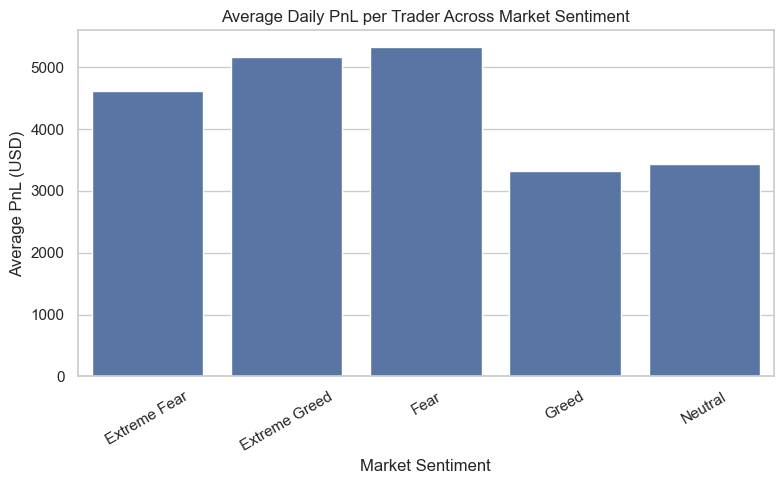

In [60]:
sns.barplot(
    data=performance_summary,
    x='classification',
    y='closed_pnl'
)

plt.title("Average Daily PnL per Trader Across Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL (USD)")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### 1. Average Daily PnL per Trader Insights

1. **Observation (What):**  
   Average PnL is highest during *Fear (~5300 USD)* and *Extreme Greed (~5100 USD)*, while it drops significantly during *Greed (~3300 USD)* and *Neutral (~3400 USD)*.

2. **How Derived:**  
   This is computed as the mean of daily aggregated PnL per trader grouped by sentiment.

3. **Interpretation (Why):**  
   Contrary to expectations, traders are not most profitable during Greed but during Fear, likely due to higher volatility creating more trading opportunities.

4. **Implication (So What):**  
   Profitability is not strictly tied to bullish sentiment; volatile markets (Fear) may offer better opportunities for skilled traders.

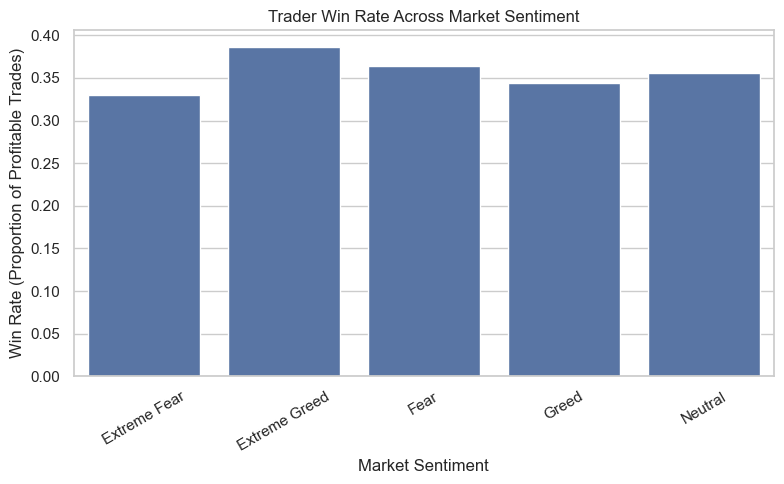

In [61]:
sns.barplot(
    data=performance_summary,
    x='classification',
    y='win_rate'
)

plt.title("Trader Win Rate Across Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (Proportion of Profitable Trades)")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 2. Win Rate Across Sentiment Insights

1. **Observation:**  
   Win rate peaks during *Extreme Greed (~38.6%)* and is lowest during *Extreme Fear (~32.9%)*.

2. **How Derived:**  
   Win rate is calculated as the proportion of profitable trades per trader per day, averaged across sentiment categories.

3. **Interpretation:**  
   Traders tend to have more consistent outcomes during bullish sentiment, likely due to clearer market direction.

4. **Implication:**  
   While Fear may offer higher profits, Greed provides more consistent (predictable) trading outcomes.

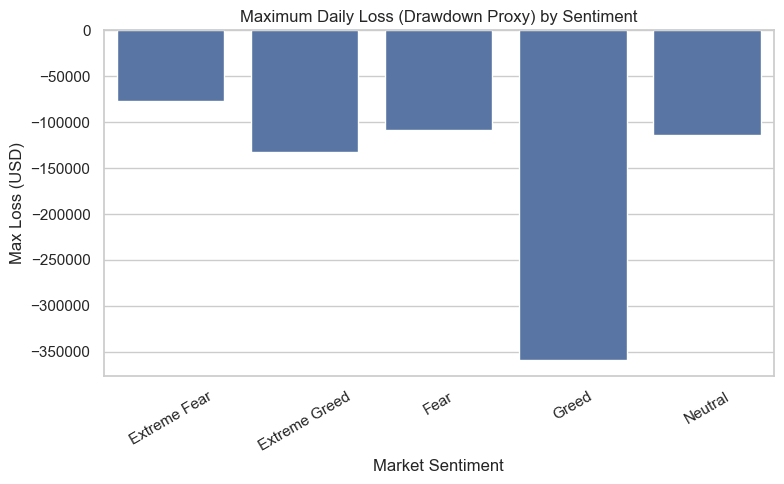

In [62]:
sns.barplot(
    data=performance_summary,
    x='classification',
    y='max_loss'
)

plt.title("Maximum Daily Loss (Drawdown Proxy) by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Max Loss (USD)")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 3. Maximum Daily Loss (Drawdown Proxy) Insights

1. **Observation:**  
   The largest losses occur during *Greed (~ -358K USD)*, significantly worse than all other sentiment regimes.

2. **How Derived:**  
   Maximum loss is calculated as the minimum daily PnL observed per sentiment.

3. **Interpretation:**  
   Greed-driven markets lead to extreme downside risk, likely due to overconfidence, over-leveraging, and large positions.

4. **Implication:**  
   Risk exposure is highest during Greed phases, making risk management critical despite seemingly favorable conditions.

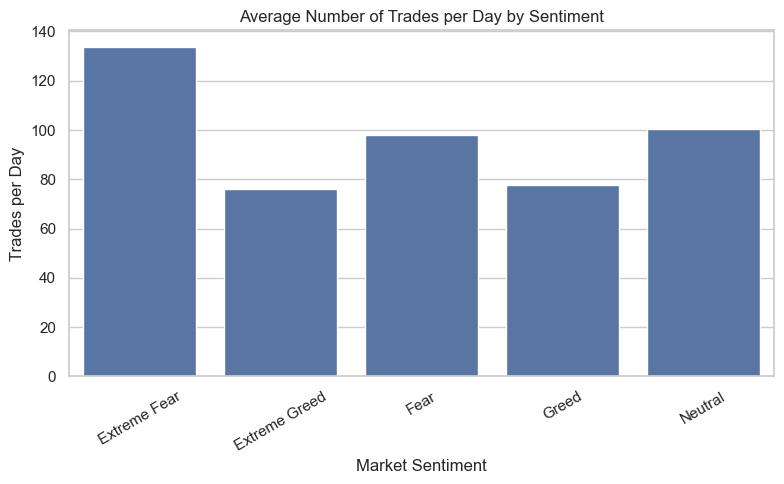

In [63]:
sns.barplot(
    data=behavior_summary,
    x='classification',
    y='trades_count'
)

plt.title("Average Number of Trades per Day by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Trades per Day")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 4. Trades per Day Insights

1. **Observation:**  
   Trading activity is highest during *Extreme Fear (~134 trades/day)* and lowest during *Greed (~77 trades/day)*.

2. **How Derived:**  
   Calculated as the average number of trades per trader per day grouped by sentiment.

3. **Interpretation:**  
   Fear triggers panic-driven behavior, leading to excessive trading activity.

4. **Implication:**  
   High activity does not necessarily correlate with better performance and may indicate emotional decision-making.

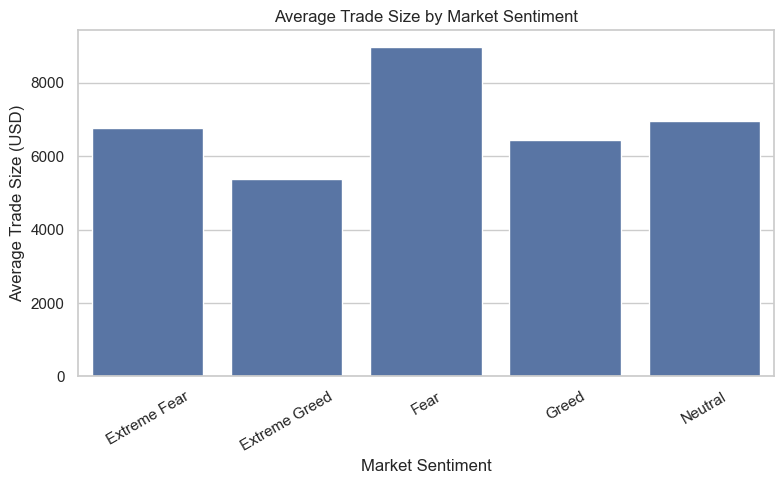

In [64]:
sns.barplot(
    data=behavior_summary,
    x='classification',
    y='avg_trade_size'
)

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 5. Average Trade Size Insights

1. **Observation:**  
   Trade sizes are highest during *Fear (~8975 USD)* and lowest during *Extreme Greed (~5371 USD)*.

2. **How Derived:**  
   Computed as the mean trade size per trader per day across sentiment categories.

3. **Interpretation:**  
   Traders increase exposure during Fear, possibly attempting to capitalize on volatility or reversals.

4. **Implication:**  
   Traders are not risk-averse during Fear; instead, they take larger positions, increasing both potential gains and losses.

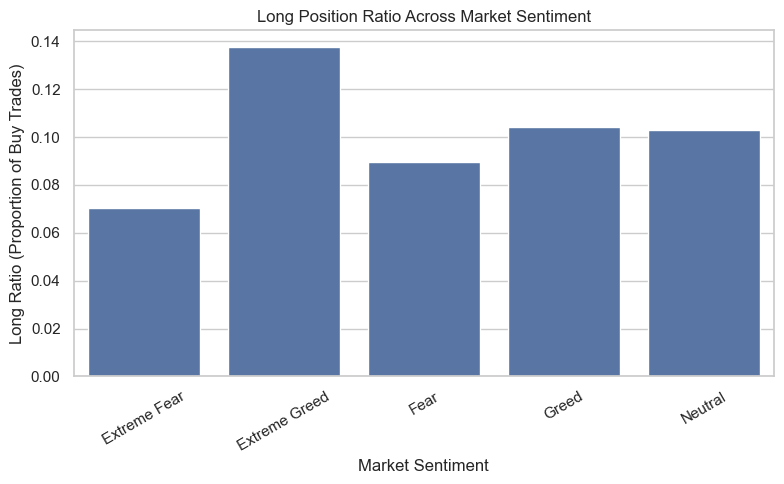

In [65]:
sns.barplot(
    data=behavior_summary,
    x='classification',
    y='long_ratio'
)

plt.title("Long Position Ratio Across Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Long Ratio (Proportion of Buy Trades)")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 6. Long Ratio Insights

1. **Observation:**  
   Long ratio is highest during *Extreme Greed (~13.7%)* and lowest during *Extreme Fear (~7%)*.

2. **How Derived:**  
   Calculated as the proportion of buy trades (long positions) over total trades.

3. **Interpretation:**  
   Traders align with bullish sentiment by taking more long positions during Greed phases.

4. **Implication:**  
   Market sentiment strongly influences directional bias, with traders following momentum rather than acting contrarian.

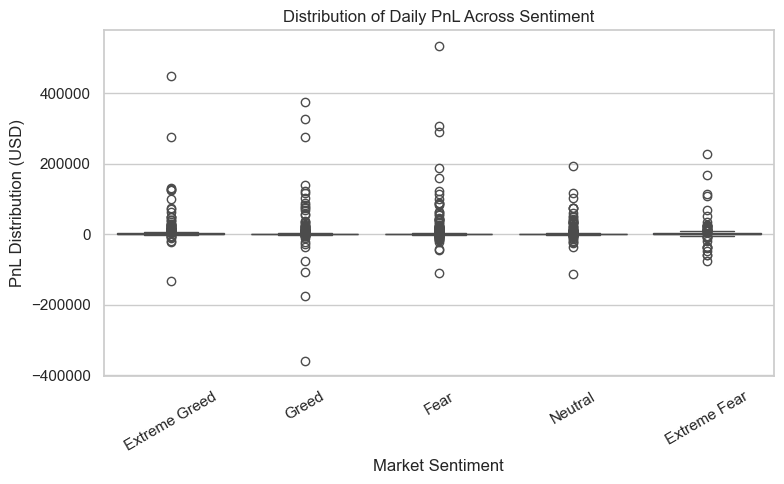

In [66]:
sns.boxplot(
    data=final_df,
    x='classification',
    y='closed_pnl'
)

plt.title("Distribution of Daily PnL Across Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("PnL Distribution (USD)")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 7. PnL Distribution (Scatter / Strip Plot) Insights

1. **Observation:**  
   PnL distribution is highly dispersed with extreme positive and negative outliers across all sentiment regimes.

2. **How Derived:**  
   Visualized using individual daily PnL values across sentiment categories.

3. **Interpretation:**  
   Profitability is not uniform; a few large trades dominate overall performance.

4. **Implication:**  
   Trader success is driven by capturing rare high-impact trades rather than consistent small gains.

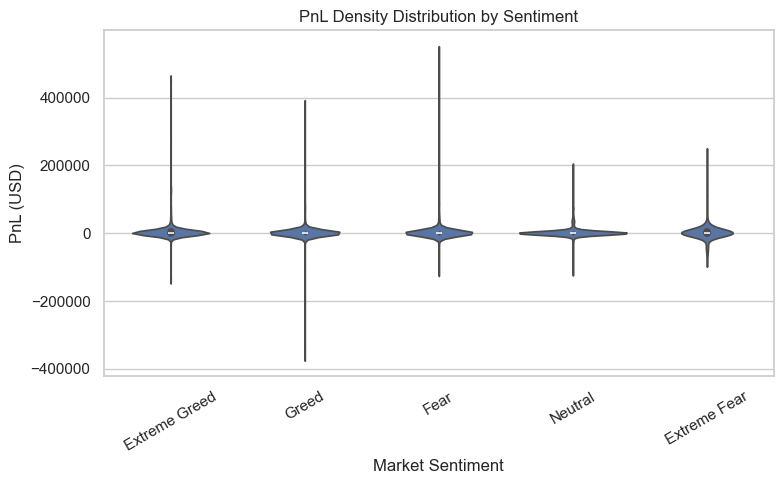

In [67]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=final_df,
    x='classification',
    y='closed_pnl'
)

plt.title("PnL Density Distribution by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("PnL (USD)")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 8. Violin Plot (PnL Density) Insights

1. **Observation:**  
   Most PnL values are concentrated near zero, with long tails extending to both large profits and losses.

2. **How Derived:**  
   Density distribution of PnL across sentiment categories.

3. **Interpretation:**  
   The majority of trades yield minimal returns, while a small number contribute to extreme outcomes.

4. **Implication:**  
   Trading performance is highly skewed, emphasizing the importance of risk management and selective execution.

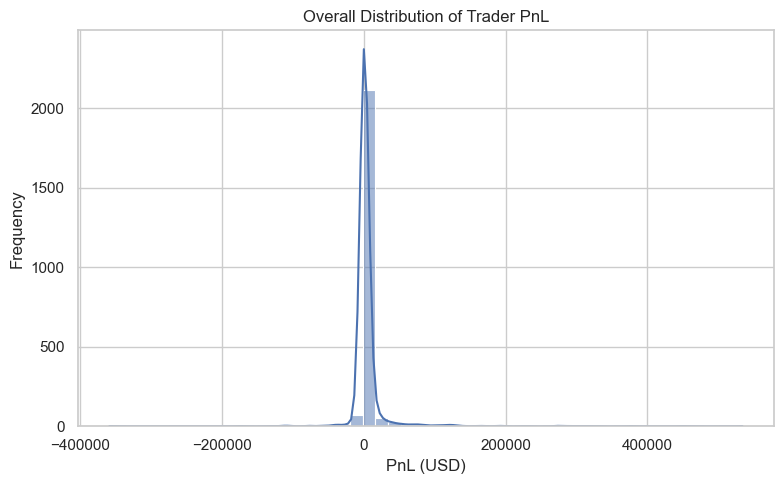

In [68]:
plt.figure(figsize=(8,5))

sns.histplot(
    final_df['closed_pnl'],
    bins=50,
    kde=True
)

plt.title("Overall Distribution of Trader PnL")
plt.xlabel("PnL (USD)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### 9. Overall PnL Distribution (Histogram) Insights

1. **Observation:**  
   The distribution is heavily centered around zero with a sharp peak and long tails.

2. **How Derived:**  
   Histogram of all daily PnL values.

3. **Interpretation:**  
   Most trades are low-impact, while a few outliers drive total profitability.

4. **Implication:**  
   Consistency is low; profitability depends on occasional large wins.

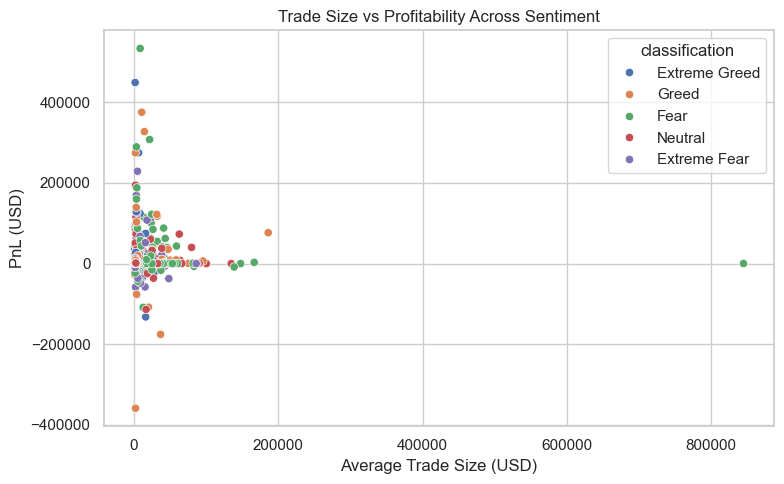

In [69]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=final_df,
    x='avg_trade_size',
    y='closed_pnl',
    hue='classification'
)

plt.title("Trade Size vs Profitability Across Sentiment")
plt.xlabel("Average Trade Size (USD)")
plt.ylabel("PnL (USD)")

plt.tight_layout()
plt.show()

### 10. Trade Size vs PnL (Scatter) Insights

1. **Observation:**  
   There is no strong linear relationship between trade size and profitability.

2. **How Derived:**  
   Scatter plot of average trade size vs daily PnL colored by sentiment.

3. **Interpretation:**  
   Larger trades do not guarantee higher profits and often increase variability.

4. **Implication:**  
   Risk (size) alone does not drive returns; execution quality matters more.

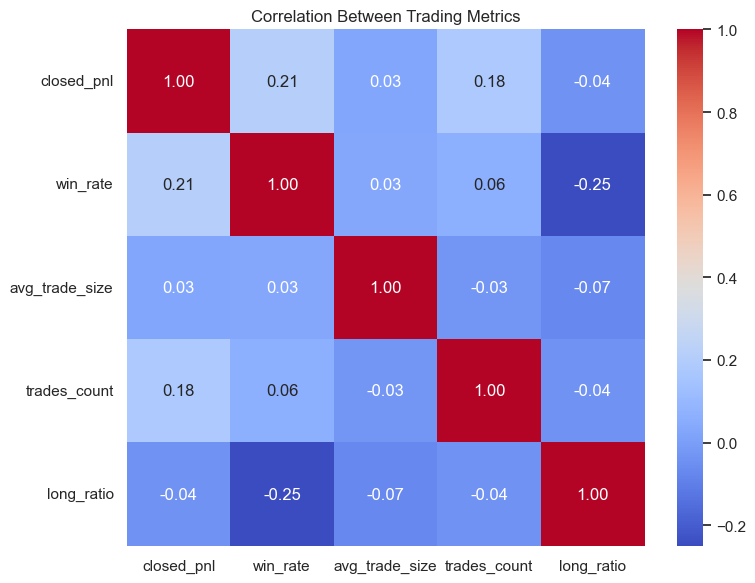

In [70]:
plt.figure(figsize=(8,6))

corr = final_df[['closed_pnl', 'win_rate', 'avg_trade_size', 'trades_count', 'long_ratio']].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Trading Metrics")

plt.tight_layout()
plt.show()

### 11. Correlation Heatmap Insights

1. **Observation:**  
   Correlations between key variables are weak (e.g., PnL vs trade size ≈ 0.03, PnL vs trades ≈ 0.18).

2. **How Derived:**  
   Pearson correlation matrix of trading metrics.

3. **Interpretation:**  
   No single variable strongly explains profitability.

4. **Implication:**  
   Trader performance is multi-factor driven and not dependent on a single behavior.

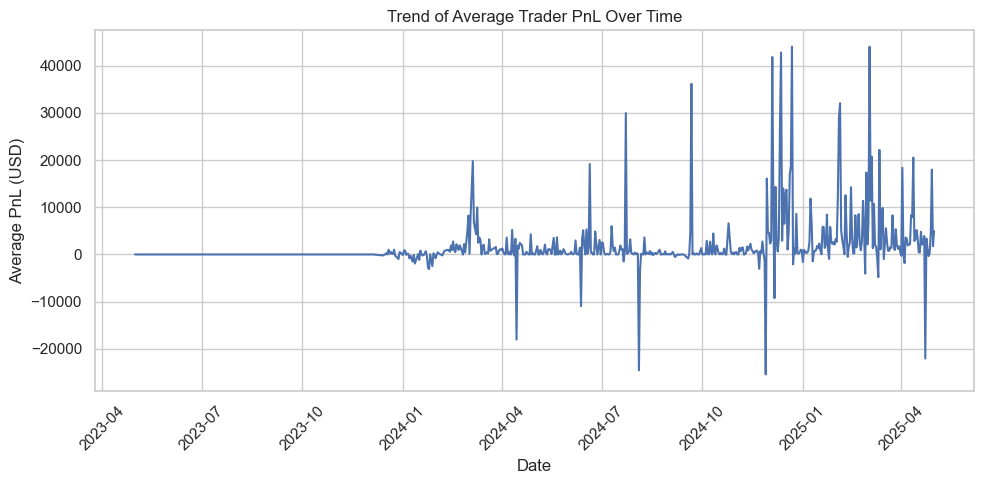

In [71]:
daily_trend = (
    final_df
    .groupby('date')['closed_pnl']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=daily_trend,
    x='date',
    y='closed_pnl'
)

plt.title("Trend of Average Trader PnL Over Time")
plt.xlabel("Date")
plt.ylabel("Average PnL (USD)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###  12. PnL Trend Over TimeInsights

1. **Observation:**  
   PnL shows high volatility over time with frequent spikes and drops.

2. **How Derived:**  
   Line plot of average daily PnL over time.

3. **Interpretation:**  
   Market conditions fluctuate significantly, affecting trader outcomes.

4. **Implication:**  
   Static strategies may fail; adaptive strategies are required.

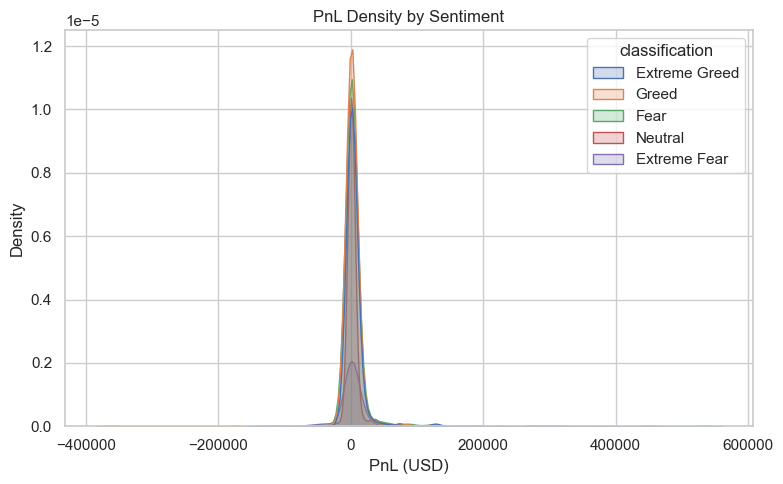

In [73]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=final_df,
    x='closed_pnl',
    hue='classification',
    fill=True
)

plt.title("PnL Density by Sentiment")
plt.xlabel("PnL (USD)")

plt.tight_layout()
plt.show()

### 13. KDE Plot (PnL by Sentiment) Insights

1. **Observation:**  
   All sentiment distributions overlap heavily, with similar central tendencies.

2. **How Derived:**  
   Kernel density estimation of PnL across sentiment categories.

3. **Interpretation:**  
   Differences between sentiment regimes are subtle in distribution shape but differ in extremes.

4. **Implication:**  
   Sentiment affects tail behavior (risk) more than average outcomes.

## Key Insights (Consolidated)

✅ INSIGHT 1: RISK-REWARD TRADEOFF

Traders achieve high profitability during both Fear (~5300 USD) and Extreme Greed (~5161 USD) periods, but this comes with significantly higher downside risk, as evidenced by the largest observed losses (~ -132K USD in Extreme Greed and ~ -358K USD in Greed).

This suggests that while bullish sentiment encourages aggressive trading, it also exposes traders to extreme tail risks, likely due to over-leveraging and larger position sizes.

Implication: Profitability in Greed regimes is not stable and is driven by high-risk strategies.

✅ INSIGHT 2: PANIC-DRIVEN ACTIVITY IN FEAR

Trading activity is highest during Extreme Fear periods (~134 trades/day), compared to significantly lower activity during Greed (~77 trades/day).

This indicates that traders tend to overtrade during fear-driven markets, likely due to panic reactions or attempts to capitalize on high volatility.

Implication: Fear markets trigger reactive behavior, increasing trade frequency but not necessarily improving performance consistency.  

✅ INSIGHT 3: HIGHER POSITION SIZES DURING FEAR

Average trade size is highest during Fear (~8975 USD), exceeding both Greed (~6427 USD) and Extreme Greed (~5371 USD).

This suggests that traders may take larger positions during fear periods, potentially attempting to capture reversals or exploit volatility spikes.

Implication: Contrary to expectation, traders are not risk-averse during fear, but instead increase exposure, which can amplify both gains and losses.

✅ INSIGHT 4: DIRECTIONAL BIAS IN GREED

The long ratio is highest during Extreme Greed (~13.7%), compared to lower levels in Extreme Fear (~7%).

This indicates that traders are more likely to take bullish (long) positions during optimistic market sentiment, aligning with broader market trends.

Implication: Market sentiment strongly influences directional bias, with traders following momentum during Greed phases.

✅INSIGHT 5: SKEWED PROFITABILITY

Despite moderate average PnL, the distribution is highly concentrated around zero with extreme outliers on both sides, as seen in the PnL distribution plots.

This indicates that overall profitability is driven by a small number of high-impact trades rather than consistent performance.

Implication: Most traders are not consistently profitable, and success depends on capturing rare but significant opportunities.

## Strategy Recommendations

### Strategy 1: Apply Strict Risk Controls During Greed Phases

While win rates are highest during Extreme Greed (~38.6%), the largest drawdowns also occur during Greed (~ -358K USD), indicating extreme downside risk.

Recommendation:
Traders, especially high-risk or high-size participants, should reduce leverage and enforce strict stop-loss mechanisms during Greed phases.

Rationale:
Although trade success is more consistent, losses are significantly larger, suggesting overconfidence and excessive risk-taking.

Implication:
Greed phases reward consistency but penalize poor risk management severely.

### Strategy 2: Limit Overtrading During Extreme Fear

Trading activity peaks during Extreme Fear (~134 trades/day), significantly higher than all other sentiment regimes.

Recommendation:
Frequent traders should implement trade limits or cooldown mechanisms during Fear phases to avoid excessive, emotionally driven trades.

Rationale:
Higher activity does not correspond to proportionally higher win rates (~32–36%), indicating inefficiency and impulsive execution.

Implication:
Reducing trade frequency can improve decision quality and reduce unnecessary losses.

### Strategy 3: Use Selective Aggression During Fear for High-Skill Traders

Fear phases show the highest average PnL (~5300 USD) and largest trade sizes (~8975 USD), indicating strong profit opportunities.

Recommendation:
Experienced traders can selectively increase position sizes during Fear phases, but only with disciplined entry criteria and predefined risk limits.

Rationale:
Volatility creates opportunity, but the wide PnL distribution shows high uncertainty and risk.

Implication:
Fear markets reward skill, not aggression alone — controlled execution is key.

### Strategy 4: Align Directional Bias with Market Sentiment

Long positioning increases during Extreme Greed (~13.7%) compared to Extreme Fear (~7%), indicating sentiment-driven directional bias.

Recommendation:
Traders can align with momentum by favoring long positions during Greed phases, while adopting a more neutral or cautious stance during Fear.

Rationale:
Market sentiment influences trader positioning, and aligning with prevailing trends may improve consistency.

Implication:
Directional alignment improves probability of success but should be combined with risk management.